# 01 · Data Profiling (RAW layer)
**Dataset:** synthetic UrbanCart Retail data (fictional). Raw files are loaded **as text** so type problems stay visible.

Goal: understand structure, completeness, distinct values and obvious defects **before** cleaning.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 160)
MART = "data/processed/mart/"


In [2]:
from python.ingestion.load_raw import load_raw
raw = load_raw()
{k: v.shape for k, v in raw.items()}

{'regions': (24, 5), 'customers': (12409, 11), 'products': (525, 8), 'orders': (56336, 8), 'order_items': (110047, 8), 'payments': (56224, 6), 'returns': (8919, 9), 'support_tickets': (6725, 10)}

## Column profile
Missing %, distinct counts, leading/trailing whitespace and unparseable numbers/dates per column.

In [3]:
from python.validation.profiling import profile_all
prof = profile_all(raw, 'raw')
prof.sort_values('missing_pct', ascending=False).head(15)[['table','column','semantic_type','missing','missing_pct','distinct','leading_trailing_space']]

,table,column,semantic_type,missing,missing_pct,distinct,leading_trailing_space
8,customers,email,text,364,2.93,11929,289
22,products,unit_cost,numeric,15,2.86,504,0
30,orders,delivery_date,date,1562,2.77,1101,0
61,support_tickets,priority,text,135,2.01,4,0
9,customers,phone,numeric,250,2.01,11760,0
20,products,brand,text,10,1.90,16,0
10,customers,gender,text,187,1.51,6,0
64,support_tickets,csat_score,numeric,72,1.07,8,0
59,support_tickets,resolved_at,date,72,1.07,6600,0
52,returns,return_reason,text,88,0.99,14,0


In [4]:
prof[prof.semantic_type.isin(['numeric','date'])][['table','column','non_numeric_values','unparseable_dates','min','max']].dropna(how='all', subset=['non_numeric_values','unparseable_dates'])

,table,column,non_numeric_values,unparseable_dates,min,max
9,customers,phone,0.00,NaN,9100141172,9999837053
11,customers,age,125.00,NaN,-1.00,999.00
13,customers,signup_date,NaN,65.00,2022-07-02 00:00:00,2031-01-01 00:00:00
21,products,unit_price,26.00,NaN,119.00,"107,999.00"
22,products,unit_cost,0.00,NaN,69.43,"94,279.15"
23,products,launch_date,NaN,0.00,2022-01-01 00:00:00,2024-12-29 00:00:00
26,orders,order_date,NaN,95.00,2023-01-01 00:00:00,2027-03-15 00:00:00
29,orders,promised_days,0.00,NaN,0,5
30,orders,delivery_date,NaN,0.00,2023-01-01 00:00:00,2026-01-05 00:00:00
35,order_items,quantity,0.00,NaN,-2.00,999.00


## Label consistency
The same category / zone / channel is spelt several ways, so a GROUP BY would split totals.

In [5]:
print(raw['products']['category'].value_counts().to_string())
print()
print(raw['orders']['channel'].value_counts(dropna=False).to_string())

category
Electronics               86
Fashion                   86
Home & Kitchen            74
Beauty                    57
Sports                    49
Grocery                   48
Books                     46
Fashion                   11
BOOKS                      8
electronics                8
fashion                    6
beauty                     6
Home&Kitchen               6
grocery                    5
Beauty & Personal Care     5
books                      4
ELECTRONICS                4
home & kitchen             4
Groceries                  3
Sport                      3
Electronic                 3
Home and Kitchen           2
sports                     1

channel
MobileApp         6090
Mobile App        6084
app               6014
web               5639
Website           5618
WEBSITE           5616
3P Marketplace    4662
Marketplace       4633
marketplace       4629
store             2332
Retail Store      2304
Offline Store     2264
NaN                451


## Rule-based quality checks & score (raw)

In [6]:
from python.validation import quality_checks as q
raw_checks = q.run_checks(raw, 'raw')
print('Overall DQ score (raw):', q.summarize(raw_checks))
raw_checks[raw_checks.failed_rows > 0].sort_values('failed_rows', ascending=False).head(20)

Overall DQ score (raw): 97.94


,layer,table,dimension,check,column,failed_rows,checked_rows,pass_rate
47,raw,orders,Consistency,allowed_values,channel,37246,55885,33.35
70,raw,order_items,Validity,extreme_outlier_3xIQR(info),line_amount,10387,109607,90.52
79,raw,payments,Consistency,allowed_values,payment_method,2933,55887,94.75
20,raw,customers,Consistency,allowed_values,gender,615,12222,94.97
62,raw,order_items,Validity,numeric_type,unit_price,592,110047,99.46
48,raw,orders,Consistency,allowed_values,order_status,563,56336,99.00
49,raw,orders,Consistency,no_extra_whitespace,order_status,563,56336,99.00
59,raw,order_items,Uniqueness,duplicate_primary_key,order_item_id,547,110047,99.50
58,raw,order_items,Uniqueness,exact_duplicate_rows,*,547,110047,99.50
21,raw,customers,Consistency,no_extra_whitespace,first_name,500,12409,95.97


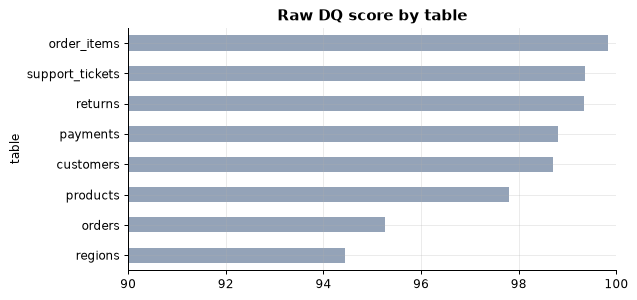

In [7]:
sc = q.quality_score(raw_checks)
ax = sc.set_index('table')['dq_score'].sort_values().plot.barh(color='#94A3B8', figsize=(7,3.5), title='Raw DQ score by table')
ax.set_xlim(90, 100); plt.show()

**Takeaways:** duplicates (rows and customers), inconsistent labels, text-typed prices, invalid dates, out-of-range quantities and orphan keys must be fixed before any KPI can be trusted.